Training on: cpu


100%|██████████| 26.4M/26.4M [00:01<00:00, 21.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 343kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.27MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.00MB/s]


Epoch 1/10 | Train Loss: 0.6465 | Val Loss: 0.5158 | Train Acc: 76.75% | Val Acc: 81.13%
Epoch 2/10 | Train Loss: 0.4610 | Val Loss: 0.4763 | Train Acc: 83.47% | Val Acc: 83.01%
Epoch 3/10 | Train Loss: 0.4245 | Val Loss: 0.4552 | Train Acc: 84.62% | Val Acc: 83.51%
Epoch 4/10 | Train Loss: 0.4019 | Val Loss: 0.4478 | Train Acc: 85.49% | Val Acc: 83.71%
Epoch 5/10 | Train Loss: 0.3862 | Val Loss: 0.4199 | Train Acc: 86.13% | Val Acc: 84.83%
Epoch 6/10 | Train Loss: 0.3754 | Val Loss: 0.4241 | Train Acc: 86.40% | Val Acc: 84.93%
Epoch 7/10 | Train Loss: 0.3656 | Val Loss: 0.4191 | Train Acc: 86.68% | Val Acc: 84.96%
Epoch 8/10 | Train Loss: 0.3574 | Val Loss: 0.4198 | Train Acc: 87.08% | Val Acc: 85.15%
Epoch 9/10 | Train Loss: 0.3523 | Val Loss: 0.4114 | Train Acc: 87.13% | Val Acc: 85.31%
Epoch 10/10 | Train Loss: 0.3462 | Val Loss: 0.4072 | Train Acc: 87.38% | Val Acc: 85.57%


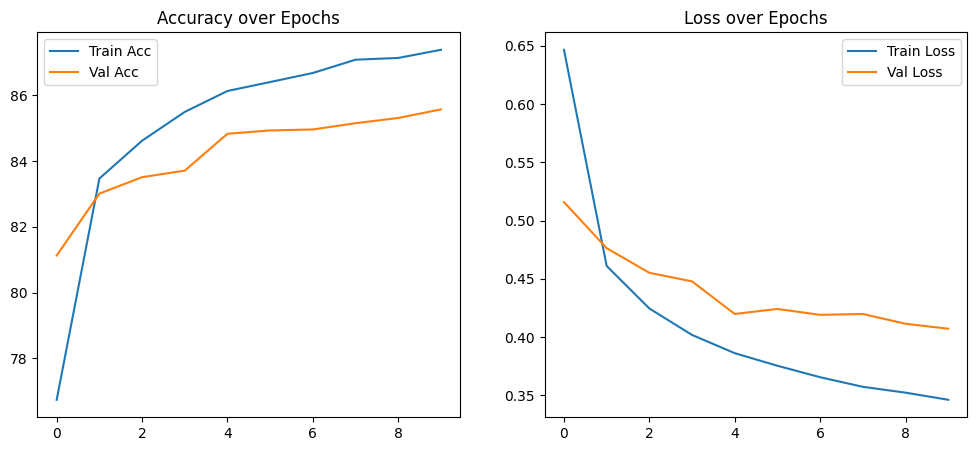

Files saved successfully!


In [1]:
# 1. IMPORTS
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import pandas as pd
import pickle

# Check if GPU is available to speed up training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

# 2. DATA LOADING (Fashion-MNIST)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

# 3. ARCHITECTURE DEFINITION
class SpiderNet(nn.Module):
    def __init__(self):
        super(SpiderNet, self).__init__()
        self.flatten = nn.Flatten() # In: (None, 28, 28) Out: (None, 784)
        self.fc1 = nn.Linear(784, 16) # In: 784 Out: 16

        # Branch 1
        self.b1_fc1 = nn.Linear(16, 8)
        self.b1_fc2 = nn.Linear(8, 8)

        # Branch 2
        self.b2_fc1 = nn.Linear(16, 12)
        self.b2_fc2 = nn.Linear(12, 8)

        # Output
        self.output = nn.Linear(16, 10) # 8+8 concatenated = 16, FashionMNIST has 10 classes
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))

        # Branch 1
        b1_in = self.relu(self.b1_fc1(x))
        b1_out = self.relu(self.b1_fc2(b1_in))
        b1_final = b1_in + b1_out # Skip Connection Add

        # Branch 2
        b2 = self.relu(self.b2_fc1(x))
        b2_final = self.relu(self.b2_fc2(b2))

        # Concatenate & Output
        merged = torch.cat((b1_final, b2_final), dim=1)
        out = self.output(merged)
        return out

model = SpiderNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. TRAINING LOOP
epochs = 10
train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []

for epoch in range(epochs):
    # Train
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_losses.append(running_loss / len(trainloader))
    train_accuracies.append(100 * correct / total)

    # Validate
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_losses.append(val_loss / len(testloader))
    val_accuracies.append(100 * correct / total)
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | Train Acc: {train_accuracies[-1]:.2f}% | Val Acc: {val_accuracies[-1]:.2f}%")

# 5. PLOTTING METRICS
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_accuracies, label='Train Acc')
plt.plot(val_accuracies, label='Val Acc')
plt.title('Accuracy over Epochs')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.show()

# 6. SAVING DELIVERABLES
weights = model.state_dict()
with open('saved_model_weights.pkl', 'wb') as f:
    pickle.dump(weights, f)

model.eval()
predictions = []
with torch.no_grad():
    for inputs, _ in testloader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        predictions.extend(predicted.cpu().numpy())

pd.DataFrame({'Id': range(len(predictions)), 'Prediction': predictions}).to_csv('submission.csv', index=False)
print("Files saved successfully!")